<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/Wallmart_Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wallmart Capstone project

Problem Statement 1:
A retail store that has multiple outlets across the country are facing issues in managing the
inventory - to match the demand with respect to supply.
Dataset Information:
The walmart.csv contains 6435 rows and 8 columns.

1. You are provided with the weekly sales data for their various outlets. Use statistical
analysis, EDA, outlier analysis, and handle the missing values to come up with various
insights that can give them a clear perspective on the following:

a. If the weekly sales are affected by the unemployment rate, if yes - which stores
are suffering the most?
b. If the weekly sales show a seasonal trend, when and what could be the reason?

c. Does temperature affect the weekly sales in any manner?

d. How is the Consumer Price index affecting the weekly sales of various stores?

e. Top performing stores according to the historical data.

f.The worst performing store, and how significant is the difference between the
highest and lowest performing stores.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks

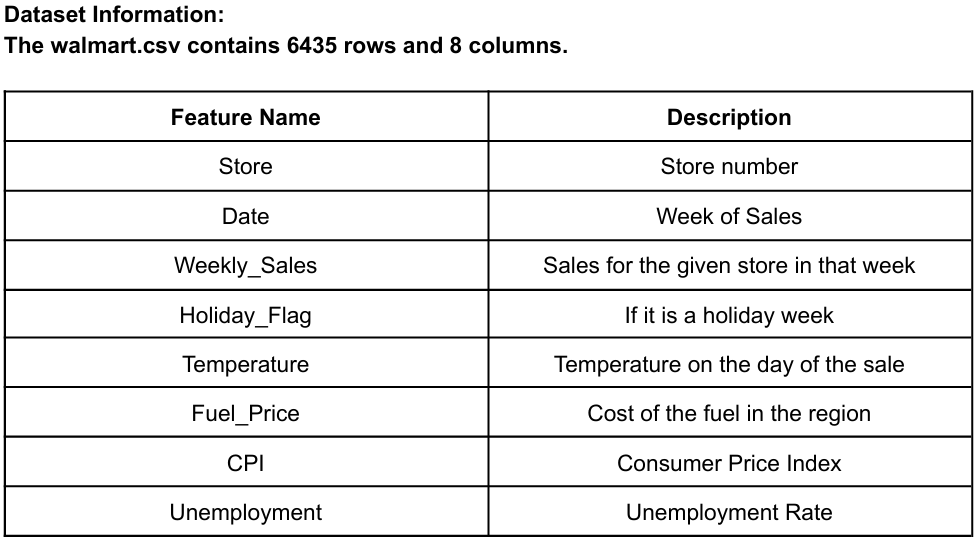

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/mydrive')

Mounted at /content/mydrive


In [3]:
df = pd.read_csv('/content/mydrive/MyDrive/Colab Notebooks/Data/Walmart/Walmart DataSet.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [8]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [7]:
df.replace(['nan','n/a'], np.nan, inplace=True)

In [10]:
#datetime conversion
df['Date'] = pd.to_datetime(df['Date'], format = '%d-%m-%Y')
df = df.sort_values('Date').reset_index(drop=True)

In [11]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,4,2010-02-05,2135143.87,0,43.76,2.598,126.442065,8.623
2,31,2010-02-05,1469252.05,0,39.05,2.572,210.752605,8.324
3,16,2010-02-05,477409.30,0,19.79,2.580,189.381697,7.039
4,11,2010-02-05,1528008.64,0,46.04,2.572,214.424881,7.368


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,6435.0,23.0,1.0,12.0,23.0,34.0,45.0,12.988182
Date,6435,2011-06-17 00:00:00.000000256,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6435.0,1046964.877562,209986.25,553350.105,960746.04,1420158.66,3818686.45,564366.622054
Holiday_Flag,6435.0,0.06993,0.0,0.0,0.0,0.0,1.0,0.255049
Temperature,6435.0,60.663782,-2.06,47.46,62.67,74.94,100.14,18.444933
Fuel_Price,6435.0,3.358607,2.472,2.933,3.445,3.735,4.468,0.45902
CPI,6435.0,171.578394,126.064,131.735,182.616521,212.743293,227.232807,39.356712
Unemployment,6435.0,7.999151,3.879,6.891,7.874,8.622,14.313,1.875885


In [14]:
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of Unique Stores: {df['Store'].nunique()}")
print(f"Number of Records per Store: \n{df.groupby('Store').size().describe()}")
total_days= (df['Date'].max()-df['Date'].min()).days
print(f'Dataset contain: {total_days} days')


Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of Unique Stores: 45
Number of Records per Store: 
count     45.0
mean     143.0
std        0.0
min      143.0
25%      143.0
50%      143.0
75%      143.0
max      143.0
dtype: float64
Dataset contain: 994 days


In [15]:
df.Holiday_Flag.value_counts()

,count
Holiday_Flag,
0,5985
1,450


In [16]:
df[(df['Holiday_Flag']==1)] \
.sort_values('Date')

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
45,37,2010-02-12,529852.70,1,46.11,2.548,209.997021,8.554
70,15,2010-02-12,682447.10,1,22.00,2.940,131.586613,8.350
71,43,2010-02-12,682918.99,1,47.99,2.548,203.201097,9.521
72,5,2010-02-12,311825.70,1,39.81,2.548,211.800470,6.566
73,39,2010-02-12,1266229.07,1,44.58,2.548,209.997021,8.554
...,...,...,...,...,...,...,...,...
6092,35,2012-09-07,984833.35,1,76.00,3.911,142.500303,8.839
6093,25,2012-09-07,671482.90,1,72.79,3.911,215.218957,7.280
6094,38,2012-09-07,490274.82,1,88.52,4.124,130.932548,10.926
6084,24,2012-09-07,1477134.75,1,72.81,4.076,138.472936,8.953


Four holidays fall within the following weeks in the dataset (not all holidays are in the data):

Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13

Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13

Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13

Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

In [95]:
out_col = df.groupby('Store').apply(lambda i : i['Weekly_Sales']. corr(i['Unemployment'])).reset_index(name = 'sales_unemp_corr')
out_col.sort_values(by = 'sales_unemp_corr').head(5)

,Store,sales_unemp_corr
37,38,-0.785290
43,44,-0.780076
38,39,-0.384681
41,42,-0.356355
40,41,-0.350630


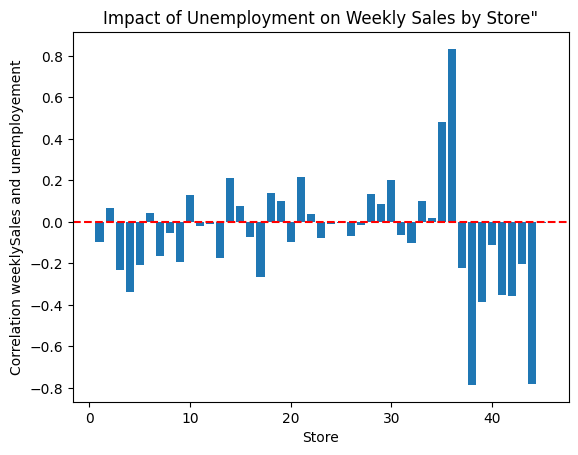

In [92]:
from matplotlib.lines import lineStyles
plt.bar(out_col['Store'],out_col['sales_unemp_corr'], label='correlation')
plt.axhline(0, linestyle = '--', color = 'red')
plt.title('Impact of Unemployment on Weekly Sales by Store"')
plt.xlabel('Store')
plt.ylabel('Correlation weeklySales and unemployement')
plt.show()

Weekkly sales and Unemployement shows the **negative corelation** that means if weekly sales increase the unemployemnt rate decrease automatically because of heavy demand and supply

In [61]:
#store which is suffering the most
#maximum employement rate
max_unemployment = out_col['Unemployment'].max()

#finding max unemployment rate affected in store
with_max_unemployement= df[df['Unemployment']==max_unemployment]
with_max_unemployement[['Store', 'Unemployment']].drop_duplicates()

,Store,Unemployment
1540,12,14.313
1551,38,14.313
1573,28,14.313


In [18]:

df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

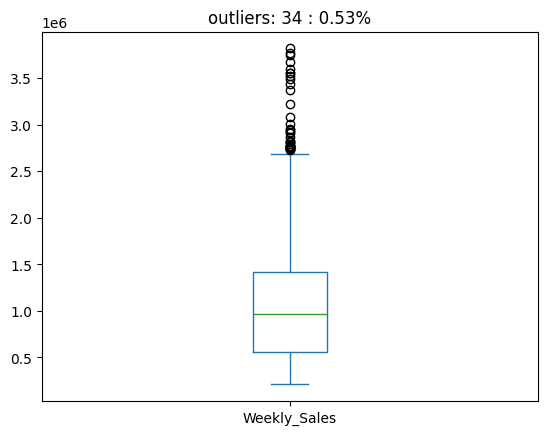

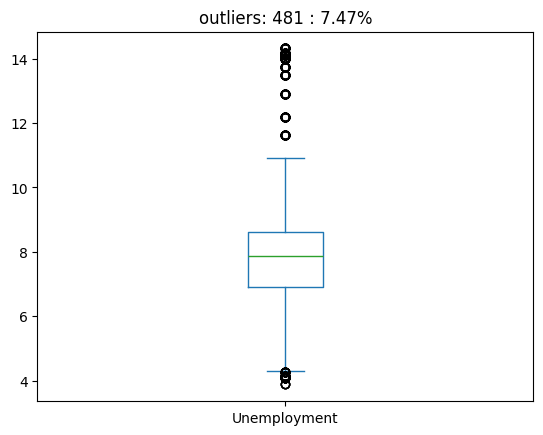

In [36]:
for col in df.columns:
  if (col in out_col.columns):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 -q1

    up_limit = q3 + (1.5*IQR)
    low_limit = q1 - (1.5* IQR)

    outliers = df[(df[col]>up_limit) | (df[col]<low_limit)]

    df[col].plot(kind= 'box', title = f'outliers: {len(outliers)} : {len(outliers)/len(df):.2%}')
    plt.show()

Outliers are present in 'Weekly_Sales', 'Holiday_Flag', 'Temperature','Unemployment' columns but these are real, meaningful events, not errors. Removing them would lose valuable patterns.

In [37]:
store = int(input('enter the store number to get the weekly sale of that store : '))
data = df[df['Store']== store]
weekly_sale = data[['Date','Weekly_Sales']].reset_index(drop = True)
print('-' * 80)
print(f'weekly sales for store {store}')
print(weekly_sale.head(5)\
      .sort_values(by ='Weekly_Sales', ascending = False))
print('-' * 80)
print(f'Total Sales for store {store} : {data['Weekly_Sales'].sum()/1000000:.2f}Millions')


enter the store number to get the weekly sale of that store : 4
--------------------------------------------------------------------------------
weekly sales for store 4
        Date  Weekly_Sales
1 2010-02-12    2188307.39
0 2010-02-05    2135143.87
2 2010-02-19    2049860.26
4 2010-03-05    1971057.44
3 2010-02-26    1925728.84
--------------------------------------------------------------------------------
Total Sales for store 4 : 299.54Millions


In [39]:
sale_by_store_mean = df.groupby('Date')['Weekly_Sales'].mean()
sale_by_store_mean


,Weekly_Sales
Date,
2010-02-05,1.105572e+06
2010-02-12,1.074148e+06
2010-02-19,1.072822e+06
2010-02-26,9.770794e+05
2010-03-05,1.041588e+06
...,...
2012-09-28,9.718867e+05
2012-10-05,1.057036e+06
2012-10-12,1.025078e+06


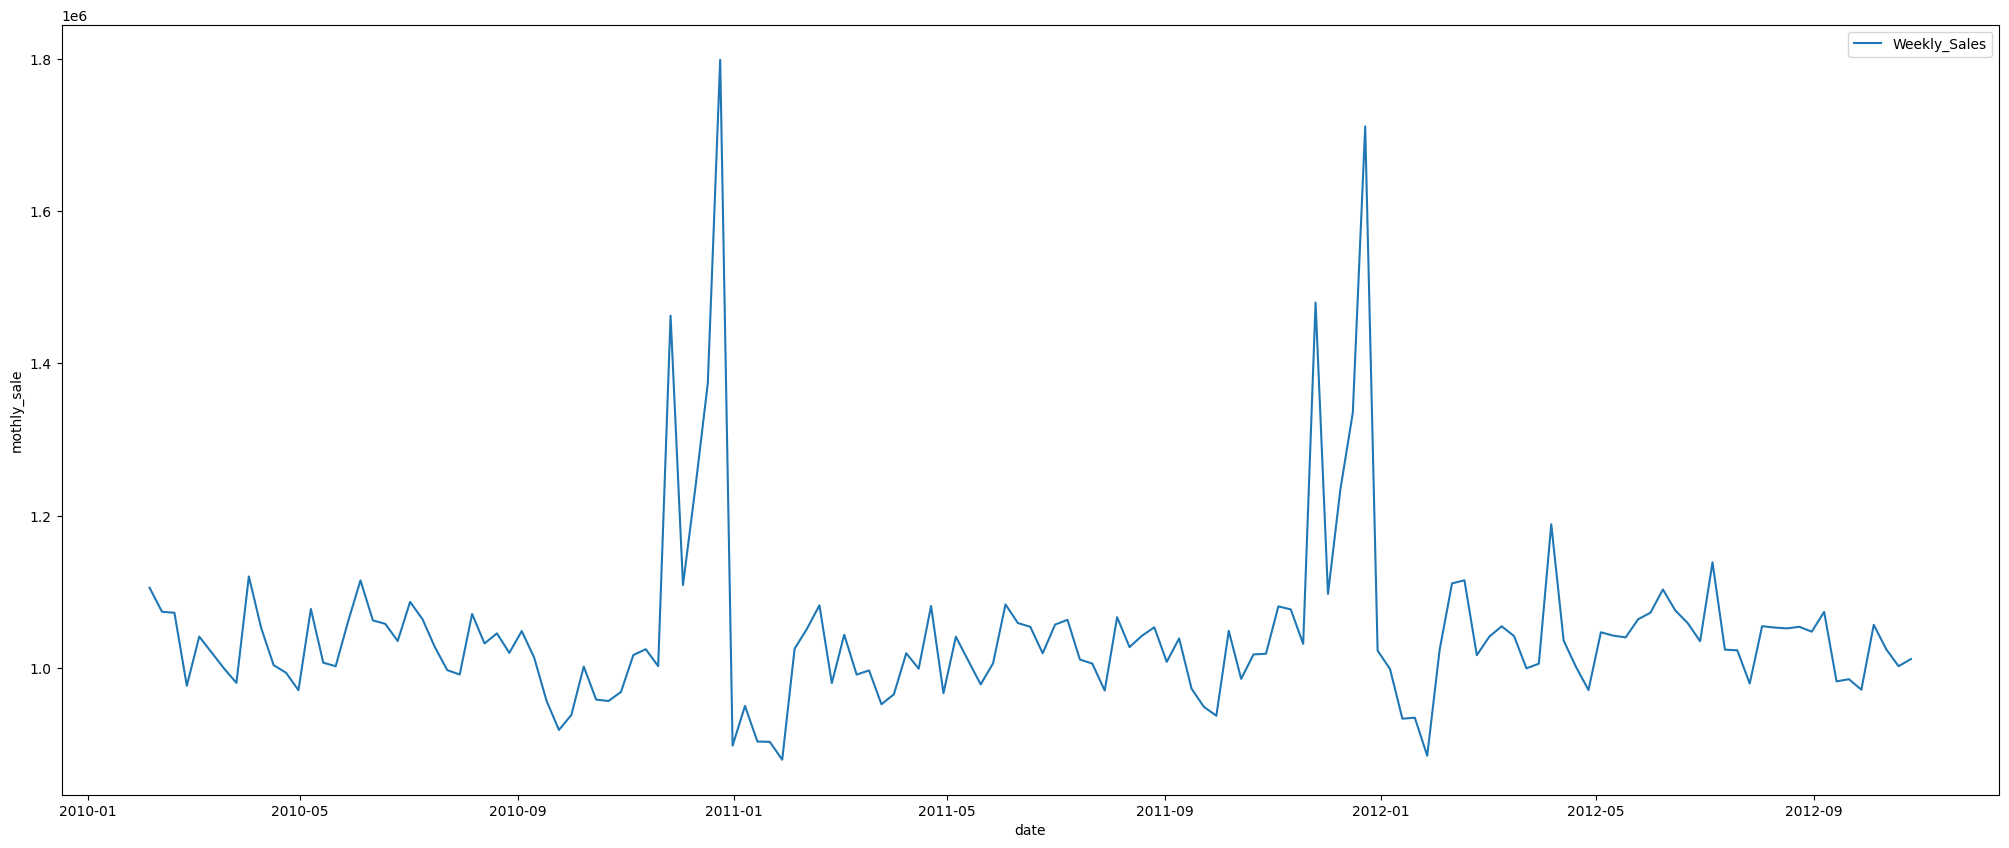

In [68]:
plt.figure(figsize = (25,10))
plt.plot(sale_by_store_mean, label = 'Weekly_Sales')

plt.xlabel('date')
plt.ylabel('mothly_sale')
plt.legend()

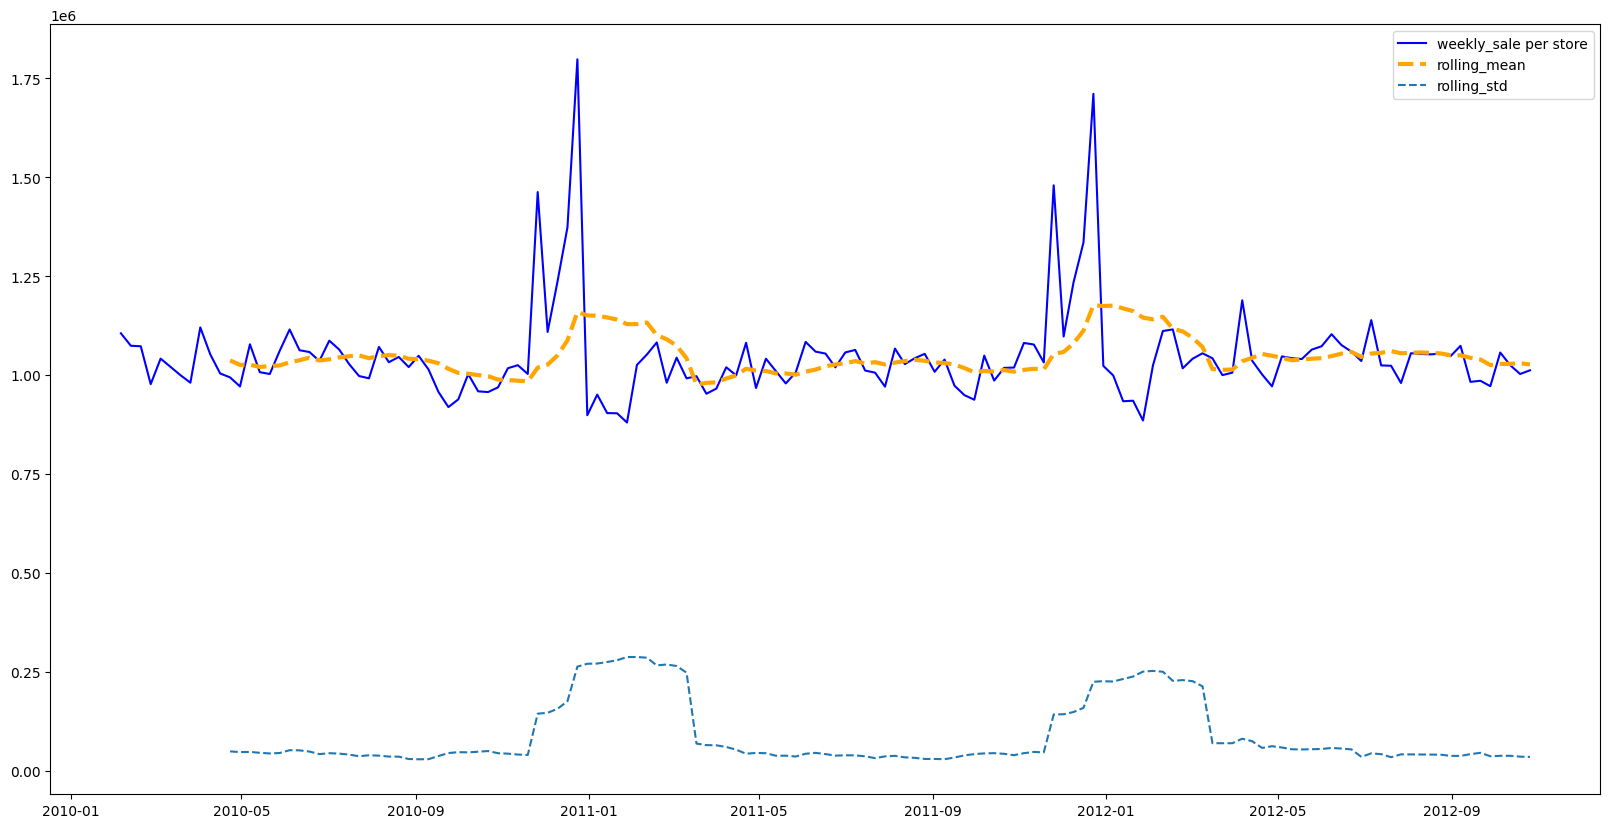

In [ ]:
#to check seasonality and trend

rolling_mean = sale_by_store_mean.rolling(window = 12).mean()
rolling_std = sale_by_store_mean.rolling(window= 12).std()

plt.figure( figsize = (20,10), )
plt.plot(sale_by_store_mean, color = 'blue', label = 'weekly_sale per store')
plt.plot(rolling_mean, color = 'orange', linewidth= 3, linestyle = '--', label = 'rolling_mean' )
plt.plot(rolling_std, linestyle = '--', label = 'rolling_std')
plt.legend()

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

Figure(640x480)


<Figure size 2000x1500 with 0 Axes>

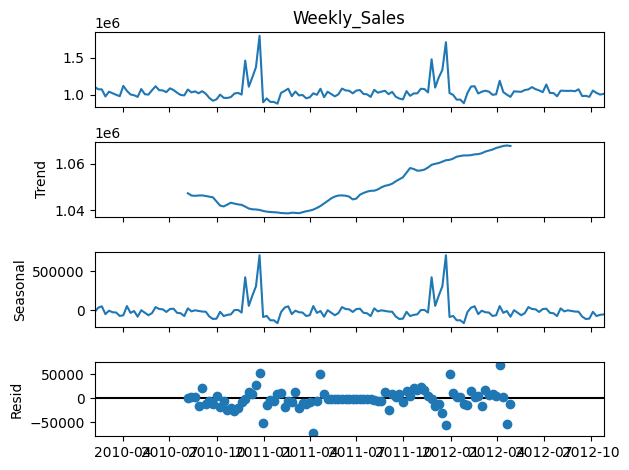

In [70]:
plt.figure(figsize=(20,15))
decompose = seasonal_decompose(sale_by_store_mean)
print(decompose.plot())
plt.show()

In [ ]:
result = adfuller(sale_by_store_mean)
print(f'{result[1]:4f}')  #data is stationary


0.000000


<Axes: ylabel='Temperature'>

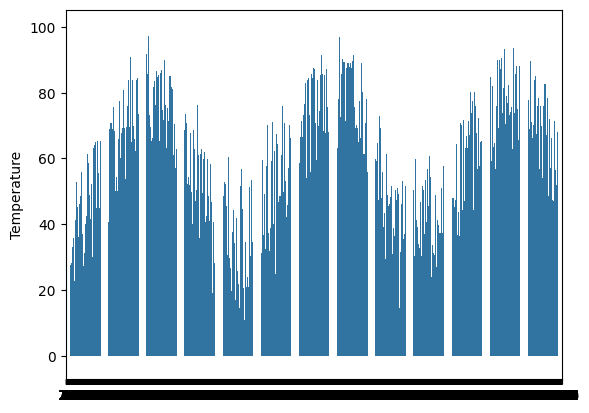

In [ ]:
sns.barplot(df['Temperature'])